# 1. Vue远程异步请求实现

## 1.1. 使用大模型获取代码

- 提示词：
    - `vue中ajax请求函数封装实现，要求请求的URL可以通过配置实现，要求请求封装成独立js文件，远程endpoint封装成独立的js文件，业务请求封装成独立的js脚本。要求使用axios模块。`

### (1) 安装

- 指令：
    - `npm install axios`
        - > 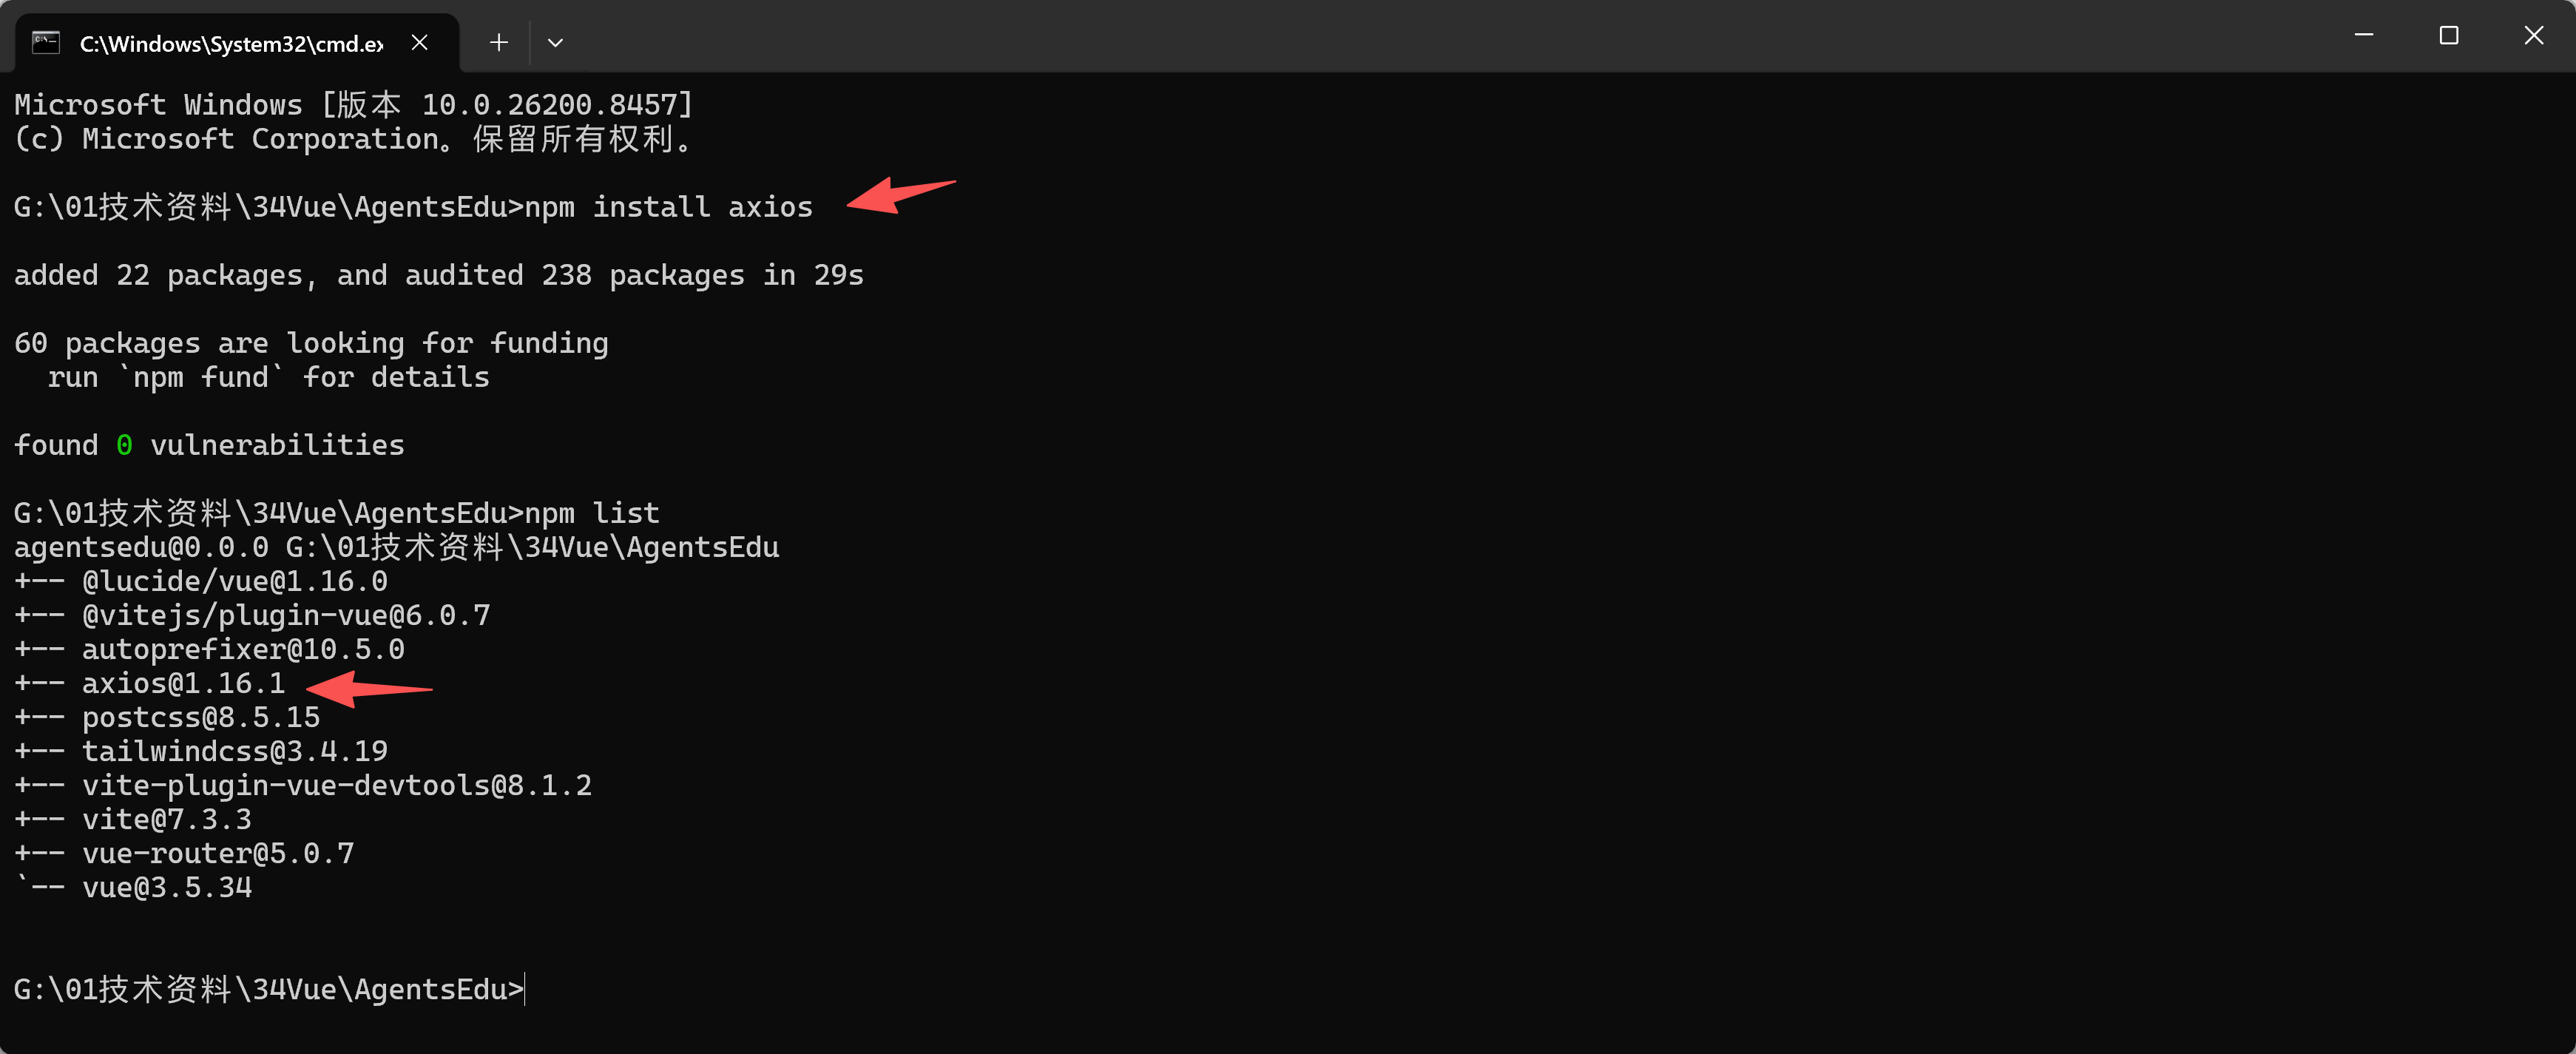

### (2) 创建目录与文件

- 创建一个api目录。
- 文件按照用途分别封装：
    - endpoint.js：封装远程服务的URL。
    - requet.js：封装Axios的请求操作。
    - index.js：封装业务请求与数据处理。
        - 如果业务请求太多，可以按照业务分类拆分成多个文件。
        - > 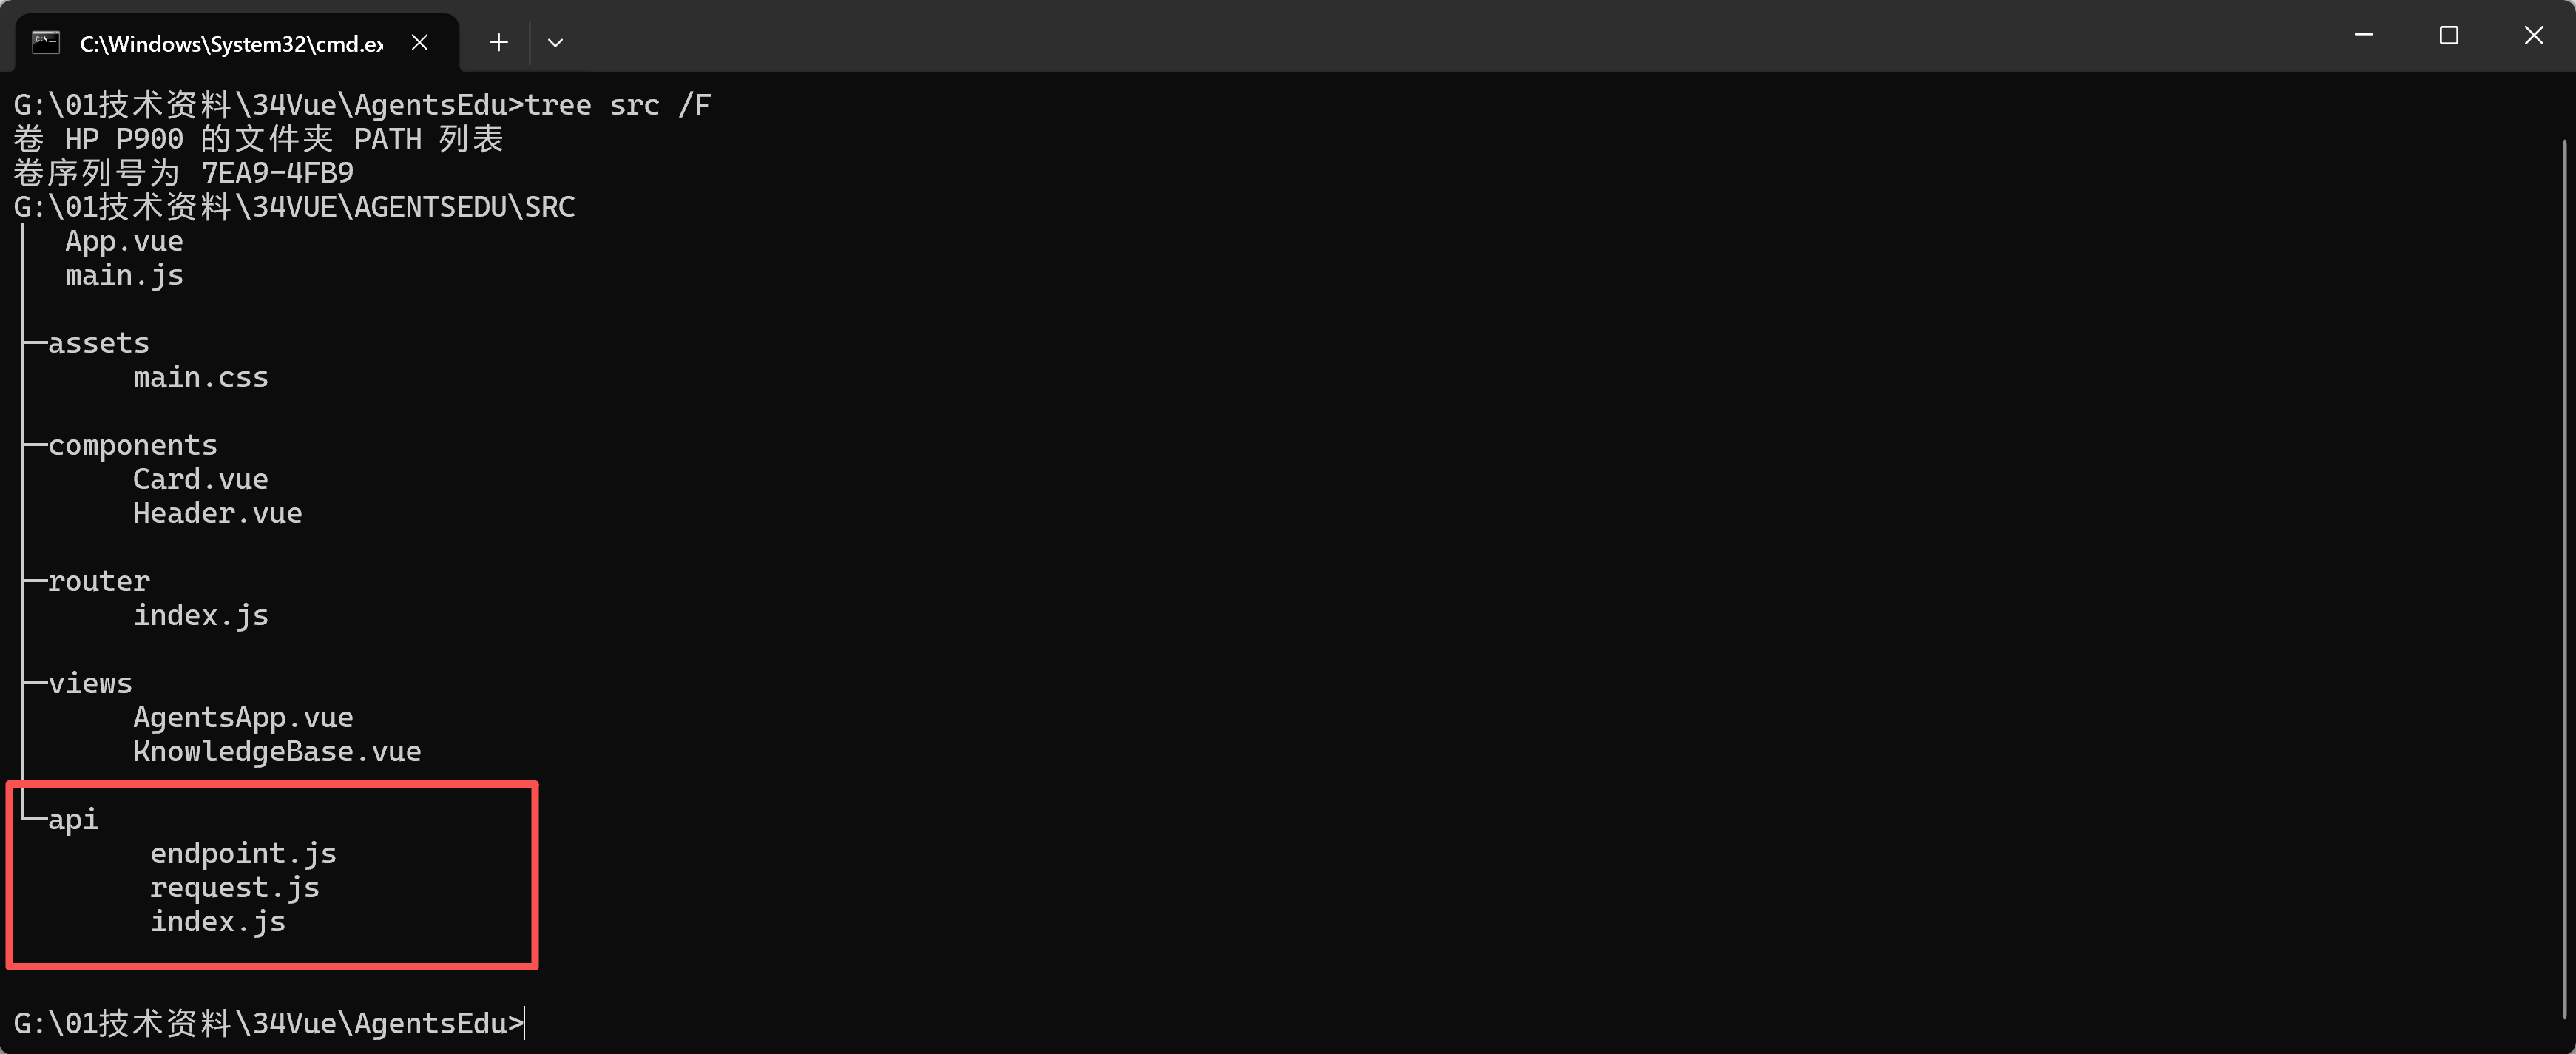

### (3) endpoint.js

- BaseURL：就是远程URL的根：
    - `baseURL: 'http://127.0.0.1:9000/api',`

- 业务URL
    - `login: '/user/login',`

- BaseURL与业务URL构成一个完整的请求地址。

```javascript
// api/endpoint.js
// 远程API端点配置文件

// 根据不同环境配置API基础地址
const env = process.env.NODE_ENV || 'development'

const config = {
  development: {
    baseURL: 'http://127.0.0.1:9000/api',
    timeout: 10000,
  },
  production: {
    baseURL: 'https://api.example.com/api',
    timeout: 20000
  }
}

// 定义所有API端点
const endpoints = {
  // 智能体应用模块
  agentsapp: {
    apps: '/apps/descriptions',
  },
  // 工具与MCP模块
  tools: {
    login: '/user/login',
    logout: '/user/logout',
  },
  // 工作流配置模块
  courseafter: {
    register: '/user/register',
    getUserInfo: '/user/info',
    updateUserInfo: '/user/update'
  },
  // 其他模块
  common: {
  }
}

// 导出配置
export default {
  ...config[env],
  endpoints,
  // 请求头配置
  headers: {
    'Content-Type': 'application/json',
    'X-Requested-With': 'XMLHttpRequest'
  }
}
```

### (4) request.js

```javascript
// utils/request.js
// Axios请求封装核心文件

import axios from 'axios'
import endpointConfig from './endpoint.js'

// 创建axios实例
const service = axios.create({
  baseURL: endpointConfig.baseURL,
  timeout: endpointConfig.timeout,
  headers: endpointConfig.headers,
  withCredentials: true // 允许携带cookie
})

// 请求拦截器
service.interceptors.request.use(
  config => {
    // 在发送请求之前做些什么
    // 例如：添加token
    const token = localStorage.getItem('token')
    if (token) {
      config.headers['Authorization'] = `Bearer ${token}`
    }
    
    // 添加时间戳防止缓存（GET请求）
    if (config.method === 'get') {
      config.params = {
        ...config.params,
        _t: Date.now()
      }
    }
    
    // 显示loading（可选）
    // store.commit('SHOW_LOADING')
    
    return config
  },
  error => {
    // 对请求错误做些什么
    console.error('Request Error:', error)
    return Promise.reject(error)
  }
)

// 响应拦截器
service.interceptors.response.use(
  response => {
    // 对响应数据做点什么
    const res = response.data
    // 关闭loading（可选）
    // store.commit('HIDE_LOADING')
    // 根据后端返回的状态码进行判断
    if (res.code !== undefined && res.code !== 200) {
      // 处理特定错误码
      switch (res.code) {
        case 401:
          // 未授权，跳转登录
          window.location.href = '/'
          break
        case 403:
          console.error('无权限访问')
          break
        case 404:
          console.error('请求资源不存在')
          break
        case 500:
          console.error('服务器错误')
          break
        default:
          console.error(res.message || '请求失败')
      }
      return Promise.reject(new Error(res.message || '请求失败'))
    }
    
    return res
  },
  error => {
    // 对响应错误做点什么
    console.error('Response Error:', error)
    
    // 关闭loading（可选）
    // store.commit('HIDE_LOADING')
    
    // 处理网络错误
    if (!error.response) {
      console.error('网络连接异常')
      return Promise.reject(new Error('网络连接异常'))
    }
    
    // 处理HTTP状态码错误
    const { status } = error.response
    switch (status) {
      case 400:
        console.error('请求参数错误')
        break
      case 401:
        console.error('未授权，请重新登录')
        window.location.href = '/'
        break
      case 403:
        console.error('拒绝访问')
        break
      case 404:
        console.error('请求资源不存在')
        break
      case 500:
        console.error('服务器内部错误')
        break
      default:
        console.error(`连接错误${status}`)
    }
    
    return Promise.reject(error)
  }
)

// 封装GET请求
export const get = (url, params = {}, config = {}) => {
  return service({
    method: 'get',
    url,
    params,
    ...config
  })
}

// 封装POST请求
export const post = (url, data = {}, config = {}) => {
  return service({
    method: 'post',
    url,
    data,
    ...config
  })
}

// 上传文件专用方法
export const uploadFile = (url, formData, config = {}) => {
  return service({
    method: 'post',
    url,
    data: formData,
    headers: {
      'Content-Type': 'multipart/form-data'
    },
    ...config
  })
}

// 导出axios实例供特殊情况使用
export default service
```

### (5) index.js

```javascript
// api/index.js
// 业务请求API封装

import { get, post, uploadFile } from './request.js'
import endpointConfig from './endpoint.js'

const { endpoints } = endpointConfig

// ==================== 智能体应用模块 ====================
export const AppsApi = {
  // 用户登录
  get_agentapps: (data) => {
    return post(endpoints.agentsapp.apps, data)
  },
  
}
// ==================== 工作流模块 ====================
// ==================== 工具模块 ====================
// ==================== 其他模块 ====================
// 统一导出所有API
export default {
  agents: AppsApi,
}

```

## 1.2. 使用FastAPI实现数据服务。

- 提示词：

```text
写一个FastAPI程序，使用post方法提供如下数据服务："[
  { title: '文件翻译', description: '上传 PDF 或粘贴链接，选择目标语言，快速获取对应语言翻译版本。', tag: 'CHATFLOW' },
  { title: '个性化记忆助手', description: '内置记忆逻辑，能在对话中实时提取并记住你的个人信息、偏好和习惯，让 AI 真正了解你。', tag: 'CHATFLOW' },
  { title: '名片识别器', description: '入门工作流：使用用户输入和 LLM 节点，上传名片照片自动整理联系人信息。', tag: '工作流' },
  { title: 'DeepResearch', description: '输入想要搜索的内容，系统就会反复执行搜索并生成报告', tag: 'CHATFLOW' },
  { title: '聊天机器人', description: '基础 Chatflow：使用内置记忆的 LLM 节点，支持多轮连续对话。', tag: 'CHATFLOW' },
  { title: '文润 · 妙笔生花', description: '专注于将英文技术文章改写为高质量的中文内容。它不仅能准确传达原文信息，更能通过多轮评审和润色...', tag: '工作流' },
]"
```

### (1) 代码提供的服务

```python
from fastapi import FastAPI
from pydantic import BaseModel

# 初始化 FastAPI 应用
app = FastAPI(title="EduAgents Services API")

# 1. 定义响应数据的 Pydantic 模型（用于数据校验和文档生成）
class AgentAppsItem(BaseModel):
    title: str
    description: str
    tag: str

# 2. 准备需要返回的业务数据
services_data = [
    { "title": "文件翻译", "description": "上传 PDF 或粘贴链接，选择目标语言，快速获取对应语言翻译版本。", "tag": "CHATFLOW" },
    { "title": "个性化记忆助手", "description": "内置记忆逻辑，能在对话中实时提取并记住你的个人信息、偏好和习惯，让 AI 真正了解你。", "tag": "CHATFLOW" },
    { "title": "名片识别器", "description": "入门工作流：使用用户输入和 LLM 节点，上传名片照片自动整理联系人信息。", "tag": "工作流" },
    { "title": "DeepResearch", "description": "输入想要搜索的内容，系统就会反复执行搜索并生成报告", "tag": "CHATFLOW" },
    { "title": "聊天机器人", "description": "基础 Chatflow：使用内置记忆的 LLM 节点，支持多轮连续对话。", "tag": "CHATFLOW" },
    { "title": "文润 · 妙笔生花", "description": "专注于将英文技术文章改写为高质量的中文内容。它不仅能准确传达原文信息，更能通过多轮评审和润色...", "tag": "工作流" },
]

# 3. 定义 POST 请求接口
@app.post("/api/apps/descriptions", response_model=list[AgentAppsItem])
# @app.get("/api/apps/descriptions", response_model=list[AgentAppsItem])
async def get_services():
    """
    获取所有 AI 数据服务列表
    """
    return services_data


if __name__ == "__main__":
    import uvicorn
    # 启动服务，监听 8000 端口
    uvicorn.run("app:app", host="0.0.0.0", port=9000, reload=True)
```

### (2) 启动服务

- 指令：
    - `python -m app`
        - > 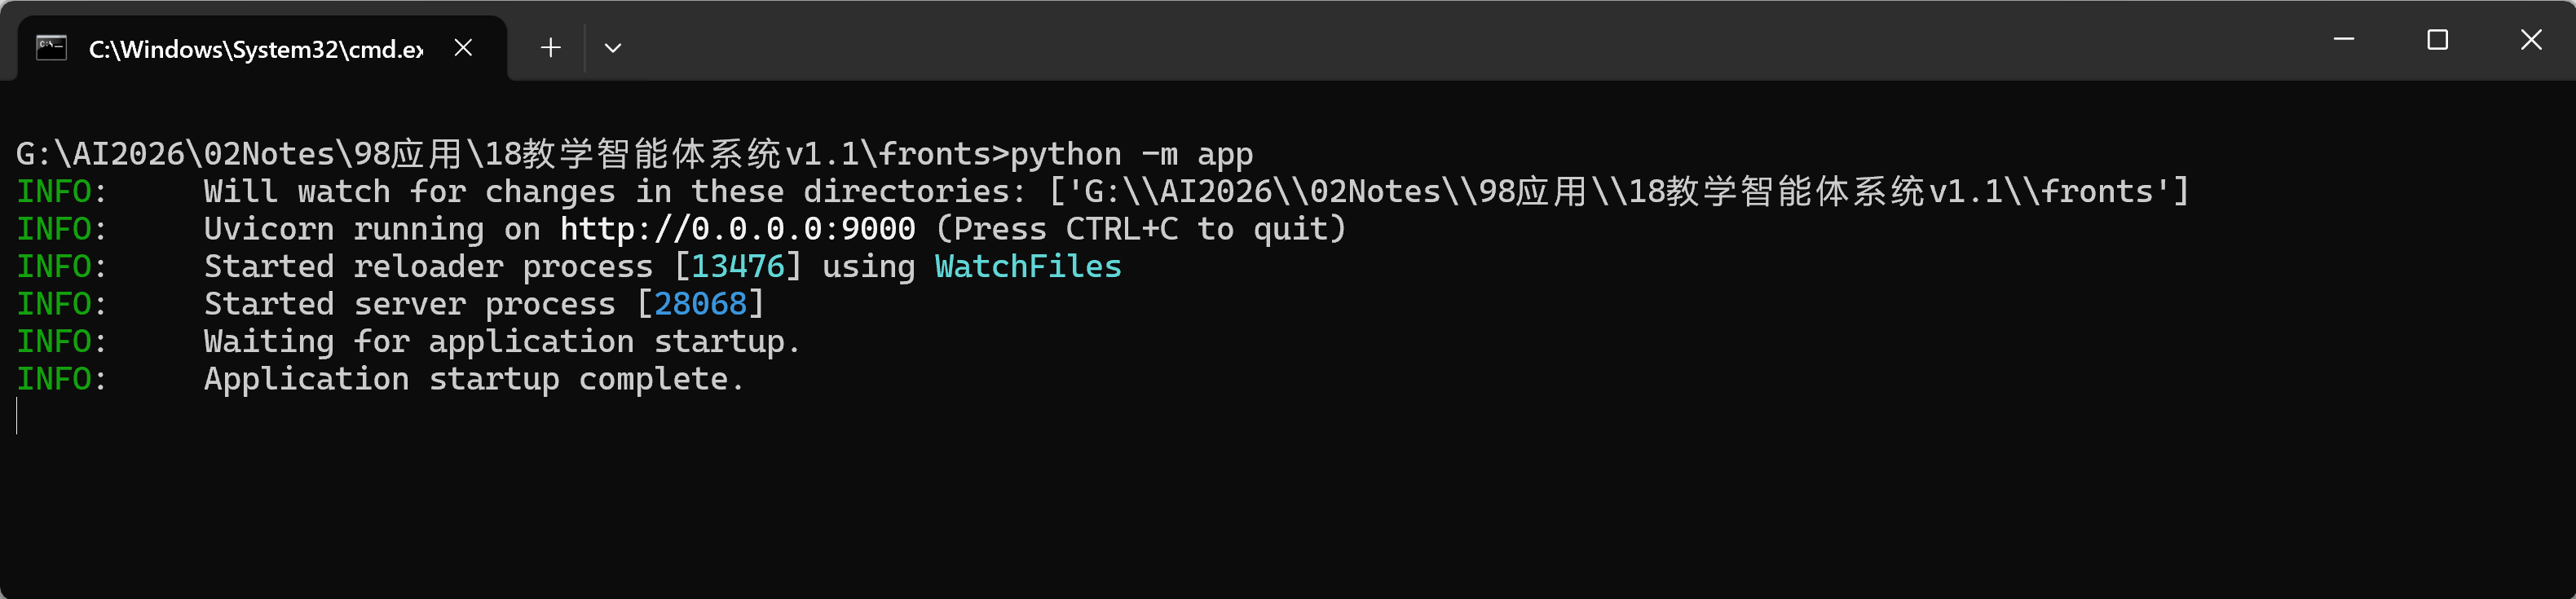

## 1.3. 在Vue中请求远程服务

### (1) 引入API

- 例子：
    -  在`<javascript setup>`中。

```
import { AppsApi, } from '@/api/index.js'
```

### (2) 调用位置

- 在Vue挂载的时候请求。
    - Vue挂载或者直接调用。

- `import { ref, computed, onMounted} from 'vue';`

```javascript
onMounted(
    ....
);
```

### (3) 调用

```javascript
const cards = ref([]);
onMounted(async () => {
  try {
    const res = await AppsApi.get_agentapps({});
    // console.log(res, res.data);
    cards.value = res;
    console.log(cards.value);
  } catch (error) {
    console.error('获取数据失败:', error);
  }
});
```

- 或者直接调用

```javascript
const cards = ref([]);
// const fetchUsers = async () => {
//   const res = await AppsApi.get_agentapps({});
//   cards.value = res;
//   // console.log(cards.value)
// };
// fetchUsers(); 
```

### (4) 跨域配置

- vite.config.js文件配置端口与跨域

```javascript
import { fileURLToPath, URL } from 'node:url'

import { defineConfig } from 'vite'
import vue from '@vitejs/plugin-vue'
import vueDevTools from 'vite-plugin-vue-devtools'

// https://vite.dev/config/
export default defineConfig({
  plugins: [
    vue(),
    vueDevTools(),
  ],
  resolve: {
    alias: {
      '@': fileURLToPath(new URL('./src', import.meta.url))
    },
  },
  server: {
    port: 3000, // 前端本地启动端口
    proxy: {
      // 拦截所有以 /api 开头的请求
      '/api': {
        target: 'http://127.0.0.1:9000', // 替换为你实际的后端 API 地址
        changeOrigin: true, // 关键配置！将请求头的 origin 改为 target 的地址，欺骗后端
        rewrite: (path) => path.replace(/^\/api/, '') // 路径重写：把 /api 前缀去掉再转发给后端
      }
    }
  }
})

```

- 其中target可以直接替换成配置的参数。

```javascript
import { fileURLToPath, URL } from 'node:url'

import { defineConfig } from 'vite'
import vue from '@vitejs/plugin-vue'
import vueDevTools from 'vite-plugin-vue-devtools'
import endpointConfig from './src/api/endpoint.js'
// https://vite.dev/config/
export default defineConfig({
  plugins: [
    vue(),
    vueDevTools(),
  ],
  resolve: {
    alias: {
      '@': fileURLToPath(new URL('./src', import.meta.url))
    },
  },
  server: {
    port: 3000, // 前端本地启动端口
    proxy: {
      // 拦截所有以 /api 开头的请求
      '/api': {
        // target: 'http://127.0.0.1:9000', // 替换为你实际的后端 API 地址
        target: endpointConfig.baseURL,
        changeOrigin: true, // 关键配置！将请求头的 origin 改为 target 的地址，欺骗后端
        rewrite: (path) => path.replace(/^\/api/, '') // 路径重写：把 /api 前缀去掉再转发给后端
      }
    }
  }
})

```